In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

In [3]:
orders = pd.read_csv("../Data/olist_orders_dataset.csv")
customers = pd.read_csv("../Data/olist_customers_dataset.csv")
payments = pd.read_csv("../Data/olist_order_payments_dataset.csv")
items = pd.read_csv("../Data/olist_order_items_dataset.csv")
products = pd.read_csv("../Data/olist_products_dataset.csv")

In [4]:
orders.head()
customers.head()
payments.head()
items.head()
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [5]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Payments:", payments.shape)
print("Items:", items.shape)
print("Products:", products.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Payments: (103886, 5)
Items: (112650, 7)
Products: (32951, 9)


In [6]:
print(orders.columns)
print(customers.columns)
print(payments.columns)
print(items.columns)
print(products.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')
Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')


In [7]:
orders.info()
customers.info()
payments.info()
items.info()
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        

In [8]:
print(orders.isnull().sum())

print(customers.isnull().sum())

print(payments.isnull().sum())

print(items.isnull().sum())

print(products.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g   

In [9]:
print("Orders:", orders.duplicated().sum())

print("Customers:", customers.duplicated().sum())

print("Payments:", payments.duplicated().sum())

print("Items:", items.duplicated().sum())

print("Products:", products.duplicated().sum())

Orders: 0
Customers: 0
Payments: 0
Items: 0
Products: 0


In [10]:
orders.describe()

payments.describe()

items.describe()

products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


### Observations

- Loaded all five datasets successfully.
- Checked rows, columns and data types.
- Identified missing values.
- Checked duplicate records.
- Generated summary statistics for numerical columns.
- Data is ready for cleaning and feature engineering.

In [11]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [12]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [13]:
orders = orders.drop_duplicates()
customers = customers.drop_duplicates()
payments = payments.drop_duplicates()
items = items.drop_duplicates()
products = products.drop_duplicates()

In [14]:
print(orders.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [15]:
products["product_category_name"] = products["product_category_name"].fillna("Unknown")

In [16]:
print(orders.shape)
print(customers.shape)
print(payments.shape)
print(items.shape)
print(products.shape)

(99441, 8)
(99441, 5)
(103886, 5)
(112650, 7)
(32951, 9)


### Data Cleaning

- Converted all date columns to datetime format.
- Removed duplicate rows.
- Handled missing values where appropriate.
- Data is now ready for feature engineering.

In [17]:
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

In [18]:
orders["shipping_time_days"] = (
    orders["order_delivered_carrier_date"] -
    orders["order_purchase_timestamp"]
).dt.days

In [19]:
orders["estimated_delay_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_estimated_delivery_date"]
).dt.days

In [20]:
orders["order_weekday"] = orders["order_purchase_timestamp"].dt.day_name()

In [21]:
orders["order_month"] = orders["order_purchase_timestamp"].dt.month_name()

In [23]:
import numpy as np
orders["delayed"] = np.where(
    orders["estimated_delay_days"] > 0,
    1,
    0
)

In [24]:
orders[[
    "delivery_time_days",
    "shipping_time_days",
    "estimated_delay_days",
    "order_weekday",
    "order_month",
    "delayed"
]].head()

,delivery_time_days,shipping_time_days,estimated_delay_days,order_weekday,order_month,delayed
0,8.0,2.0,-8.0,Monday,October,0
1,13.0,1.0,-6.0,Tuesday,July,0
2,9.0,0.0,-18.0,Wednesday,August,0
3,13.0,3.0,-13.0,Saturday,November,0
4,2.0,0.0,-10.0,Tuesday,February,0


In [25]:
orders["delayed"].value_counts()

delayed
0    92906
1     6535
Name: count, dtype: int64

### Feature Engineering

- Created delivery_time_days
- Created shipping_time_days
- Created estimated_delay_days
- Extracted order_weekday
- Extracted order_month
- Created target variable (delayed)

In [26]:
df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [27]:
df = df.merge(
    payments,
    on="order_id",
    how="left"
)

In [28]:
df = df.merge(
    items,
    on="order_id",
    how="left"
)

In [29]:
df = df.merge(
    products,
    on="product_id",
    how="left"
)

In [30]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,shipping_time_days,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2.0,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2.0,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2.0,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0.0,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


In [31]:
print(df.shape)

(118434, 36)


In [32]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     2074
order_delivered_customer_date    3397
order_estimated_delivery_date       0
delivery_time_days               3397
shipping_time_days               2074
estimated_delay_days             3397
order_weekday                       0
order_month                         0
delayed                             0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
order_item_id                     830
product_id                        830
seller_id                         830
shipping_limit_date               830
price       

In [34]:
df.to_csv("final_olist_dataset.csv", index=False)

### Data Merging

- Merged Orders and Customers using `customer_id`.
- Merged Payments using `order_id`.
- Merged Order Items using `order_id`.
- Merged Products using `product_id`.
- Created one final dataset for EDA, SQL, and Machine Learning.

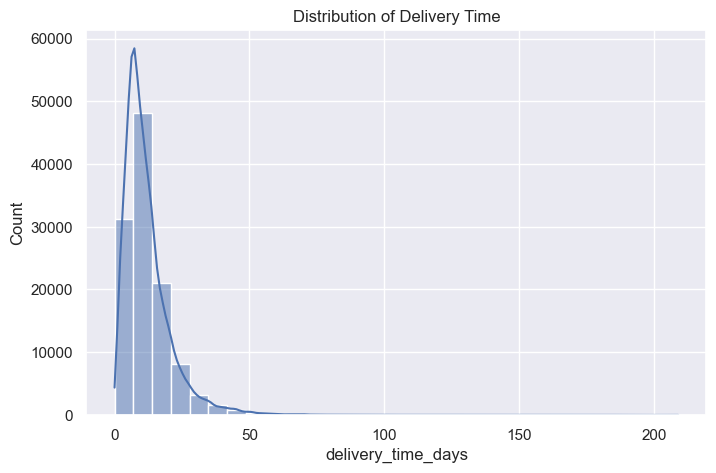

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["delivery_time_days"], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.show()

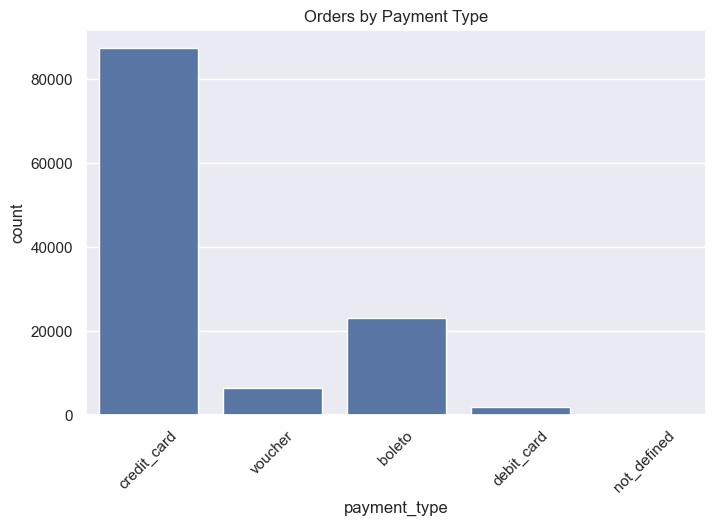

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="payment_type")
plt.xticks(rotation=45)
plt.title("Orders by Payment Type")
plt.show()

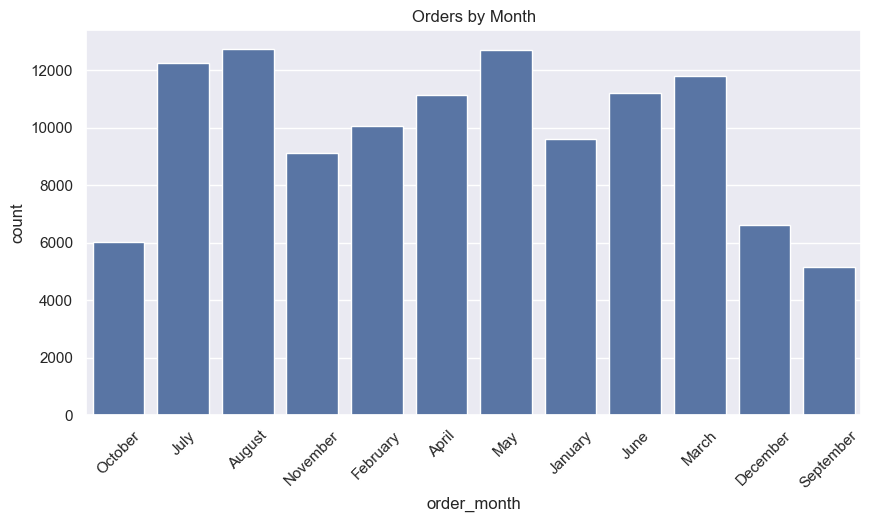

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="order_month")
plt.xticks(rotation=45)
plt.title("Orders by Month")
plt.show()

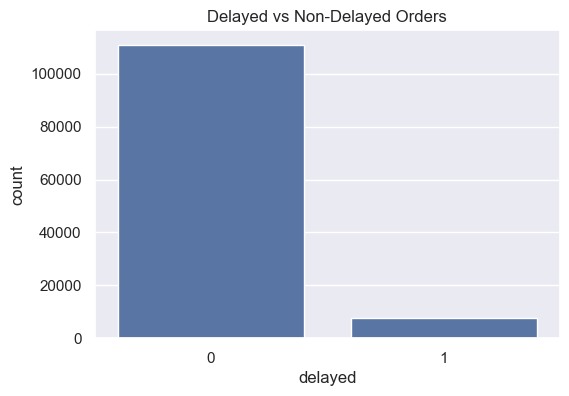

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="delayed")
plt.title("Delayed vs Non-Delayed Orders")
plt.show()

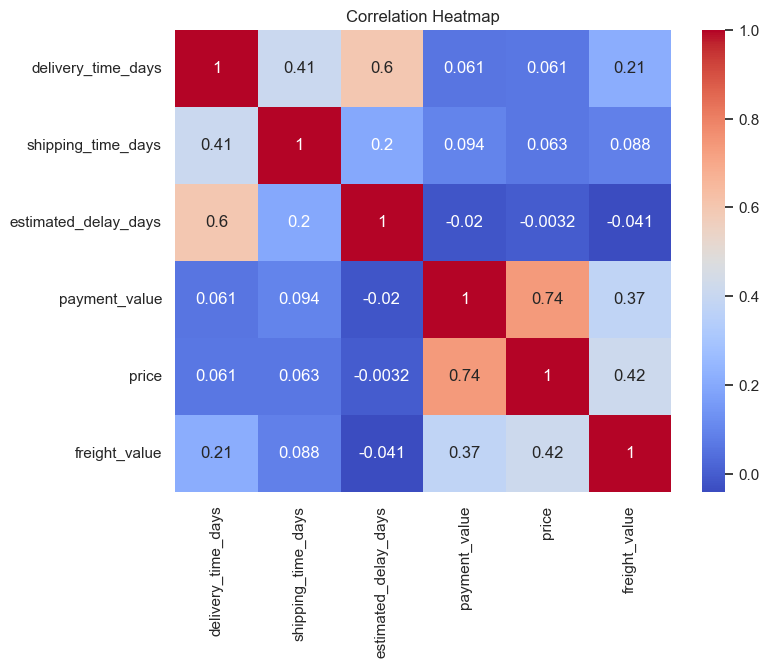

In [40]:
plt.figure(figsize=(8,6))

corr = df[[
    "delivery_time_days",
    "shipping_time_days",
    "estimated_delay_days",
    "payment_value",
    "price",
    "freight_value"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

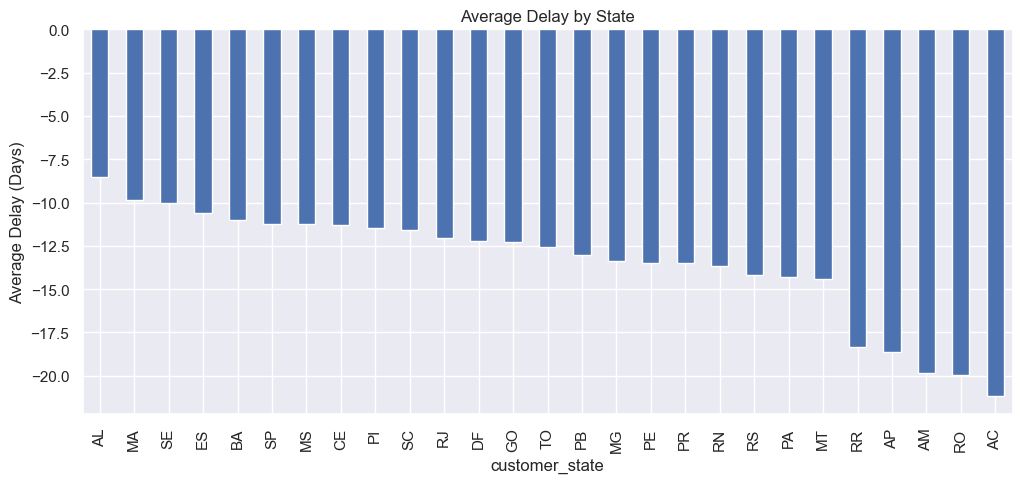

In [41]:
state_delay = df.groupby("customer_state")["estimated_delay_days"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
state_delay.plot(kind="bar")
plt.title("Average Delay by State")
plt.ylabel("Average Delay (Days)")
plt.show()

In [42]:
plt.savefig("../visuals/delivery_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Exploratory Data Analysis (EDA)

- Created distribution plot.
- Compared payment methods.
- Analyzed monthly order trends.
- Visualized delayed vs non-delayed orders.
- Generated correlation heatmap.
- Analyzed average delivery delay by customer state.

# Step 10: Business Insights

### Business Insights

1. Most orders are delivered within a reasonable number of days, while only a small number experience significant delays.

2. Credit Card is the most frequently used payment method among customers.

3. Order volume varies across different months, indicating seasonal demand patterns.

4. A majority of orders are delivered on time, while delayed orders represent a smaller portion of the dataset.

5. Delivery delays differ across customer states, suggesting that location may influence delivery performance.

In [43]:
import sqlite3

In [44]:
df.to_csv("../Data/final_olist_dataset.csv", index=False)